Machine Translation Seq2Seq, LSTMs

Machine Translations : Converting a German sentence to its English counterpart.

Importing Libraries

In [ ]:
import string
import re
from numpy import array, argmax, random, take
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, RepeatVector
from tensorflow.keras.preprocessing.text import Tokenizer # this we have to use for 2.x tensorflow 
#from keras.preprocessing.text import Tokenizer
from keras.callbacks import ModelCheckpoint
from keras.preprocessing.sequence import pad_sequences
from keras.models import load_model
from keras import optimizers
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.max_colwidth', 200)

Load the Data

In [3]:
# function to read raw text file
def read_text(filename):
        # open the file
        file = open(filename, mode='rt', encoding='utf-8') # rt is read in text mode
        
        # read all text
        text = file.read()
        file.close()
        return text

In [4]:
# split a text into sentences
def to_lines(text):
    sents = text.strip().split('\n')
    sents = [i.split('\t') for i in sents]
    return sents

In [6]:
data = read_text("deu.txt")
deu_eng = to_lines(data)
deu_eng = array(deu_eng)

In [7]:
deu_eng = deu_eng[:50000,:] # we are taking only 50k records to reduce the training time of the model.

Text Cleaning / Preprocessing

In [8]:
# Remove punctuation
deu_eng[:,0] = [s.translate(str.maketrans('', '', string.punctuation)) for s in deu_eng[:,0]] # this will remove all the punctuation from the text
deu_eng[:,1] = [s.translate(str.maketrans('', '', string.punctuation)) for s in deu_eng[:,1]]

deu_eng

array([['Go', 'Geh',
        'CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #8597805 (Roujin)'],
       ['Hi', 'Hallo',
        'CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #380701 (cburgmer)'],
       ['Hi', 'Grüß Gott',
        'CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #659813 (Esperantostern)'],
       ...,
       ['Im giving up smoking', 'Ich höre mit dem Rauchen auf',
        'CC-BY 2.0 (France) Attribution: tatoeba.org #256952 (minshirui) & #407184 (MUIRIEL)'],
       ['Im glad I was nearby', 'Ich bin froh dass ich in der Nähe war',
        'CC-BY 2.0 (France) Attribution: tatoeba.org #2547219 (CK) & #3448316 (Pfirsichbaeumchen)'],
       ['Im glad Tom has gone', 'Ich bin froh dass Tom weg ist',
        'CC-BY 2.0 (France) Attribution: tatoeba.org #2547217 (CK) & #5299642 (Pfirsichbaeumchen)']],
      dtype='<U537')

In [9]:
# convert text to lowercase
for i in range(len(deu_eng)):
    deu_eng[i,0] = deu_eng[i,0].lower()
    deu_eng[i,1] = deu_eng[i,1].lower()

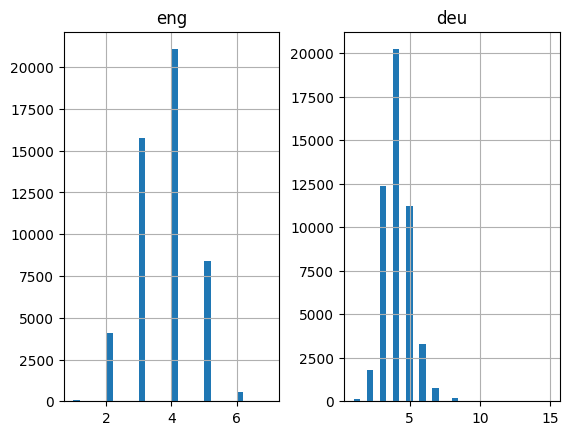

In [10]:
# empty lists
eng_l = []
deu_l = []

# populate the lists with sentence lengths
for i in deu_eng[:,0]:
      eng_l.append(len(i.split()))

for i in deu_eng[:,1]:
      deu_l.append(len(i.split()))

length_df = pd.DataFrame({'eng':eng_l, 'deu':deu_l})

length_df.hist(bins = 30)
plt.show()

A Seq2Seq model requires that we convert both the input and the output sentences into integer sequences of fixed length.    
Now, vectorize our text data by using Keras’s Tokenizer() class. It will turn our sentences into sequences of integers. We can then pad those sequences with zeros to make all the sequences of the same length.
Prepare tokenizers for both the German and English sentences

In [11]:
# function to build a tokenizer
def tokenization(lines):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(lines)
    return tokenizer

In [12]:
# prepare english tokenizer
eng_tokenizer = tokenization(deu_eng[:, 0])
eng_vocab_size = len(eng_tokenizer.word_index) + 1

eng_length = 8
print('English Vocabulary Size: %d' % eng_vocab_size)

English Vocabulary Size: 6256


In [13]:
# prepare Deutch tokenizer
deu_tokenizer = tokenization(deu_eng[:, 1])
deu_vocab_size = len(deu_tokenizer.word_index) + 1

deu_length = 8
print('Deutch Vocabulary Size: %d' % deu_vocab_size)

Deutch Vocabulary Size: 10329


We tokenized the data — i.e., converted the text to numerical values. This allows the neural network to perform operations on the input data.
When we run the tokenizer, it creates a word index, which is then used to convert each sentence to a vector.

In [14]:
# encode and pad sequences
def encode_sequences(tokenizer, length, lines):
    seq = tokenizer.texts_to_sequences(lines)
    # pad sequences with 0 values
    seq = pad_sequences(seq, maxlen=length, padding='post')
    return seq

When we feed our sequences of word IDs into the model, each sequence needs to be the same length. To achieve this, padding is added to any sequence that is shorter than the max length (i.e. shorter than the longest sentence).

Model Building

First, let’s breakdown the architecture of an RNN at a high level.
there are a few parts of the model :

Inputs. Input sequences are fed into the model with one word for every time step. Each word is encoded as a unique integer so that it maps to the German dataset vocabulary.

Embedding Layers. Embeddings are used to convert each word to a vector. The size of the vector depends on the complexity of the vocabulary.

LSTM Layer (Encoder). This is where the context from word vectors in previous time steps is applied to the current word vector.

Dense Layers (Decoder). These are typical fully connected layers used to decode the encoded input into the correct translation sequence.

he outputs are returned as a sequence of integers or one-hot encoded vectors which can then be mapped to the English dataset vocabulary.

In [15]:
from sklearn.model_selection import train_test_split

# split data into train and test set
train, test = train_test_split(deu_eng, test_size=0.2, random_state = 12)

It’s time to encode the sentences. We will encode German sentences as the input sequences and English sentences as the target sequences. This has to be done for both the train and test datasets.

In [16]:
# prepare training data
trainX = encode_sequences(deu_tokenizer, deu_length, train[:, 1])
trainY = encode_sequences(eng_tokenizer, eng_length, train[:, 0])

# prepare validation data
testX = encode_sequences(deu_tokenizer, deu_length, test[:, 1])
testY = encode_sequences(eng_tokenizer, eng_length, test[:, 0])

Define the Model

In [17]:
# build NMT model
def define_model(in_vocab,out_vocab, in_timesteps,out_timesteps,units):
    model = Sequential()
    model.add(Embedding(in_vocab, units, input_length=in_timesteps, mask_zero=True))
    model.add(LSTM(units))
    model.add(RepeatVector(out_timesteps))
    model.add(LSTM(units, return_sequences=True))
    model.add(Dense(out_vocab, activation='softmax'))
    return model

In [18]:
# model compilation
model = define_model(deu_vocab_size, eng_vocab_size, deu_length, eng_length, 512)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
rms = optimizers.RMSprop(learning_rate=0.001)
model.compile(optimizer=rms, loss='sparse_categorical_crossentropy')

We are using the RMSprop optimizer in this model as it’s usually a good choice when working with recurrent neural networks.
Here I have used ‘sparse_categorical_crossentropy‘ as the loss function. This is because the function allows us to use the target sequence as is, instead of the one-hot encoded format. One-hot encoding the target sequences using such a huge vocabulary might consume our system’s entire memory.

Fit the Model

ModelCheckpoint() function to save the model with the lowest validation loss. I personally prefer this method over early stopping.

In [27]:
#filename = 'model24'
filename = 'model24.keras'
checkpoint = ModelCheckpoint(filename, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

# train model
history = model.fit(trainX, trainY.reshape(trainY.shape[0], trainY.shape[1], 1),
                    epochs=30, batch_size=512, validation_split = 0.2,callbacks=[checkpoint], 
                    verbose=1)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 5.7710
Epoch 1: val_loss improved from inf to 3.13192, saving model to model.h1.24_jan_19.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - loss: 5.7476 - val_loss: 3.1319
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 3.0135
Epoch 2: val_loss improved from 3.13192 to 2.86649, saving model to model.h1.24_jan_19.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - loss: 3.0126 - val_loss: 2.8665
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 2.8315
Epoch 3: val_loss improved from 2.86649 to 2.80574, saving model to model.h1.24_jan_19.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - loss: 2.8314 - val_loss: 2.8057
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.7815
Epoch 4: val_loss improved from 2.80574 to 2.79015, saving model to model.h1.24_jan_19.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step - loss: 2.7815 - val_loss: 2.7901
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 2.7577
Epoch 5: val_los

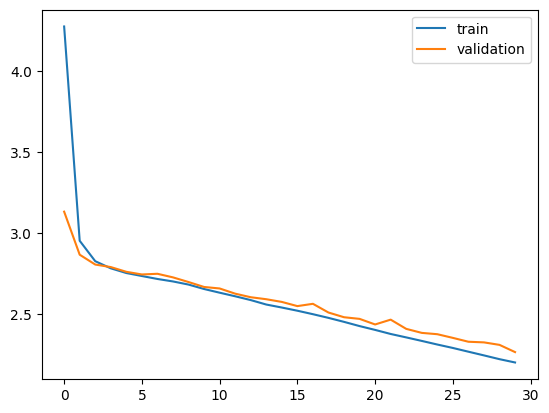

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.show()

Prediction on unseen data

In [ ]:
#model = load_model('model24')
#model = load_model('model24.keras')
#preds = model.predict_classes(testX.reshape((testX.shape[0],testX.shape[1])))

import numpy as np
model = load_model('model24.keras')
preds = model.predict(testX.reshape((testX.shape[0], testX.shape[1]))) # we are reshaping the testX to 2D array
preds_classes = np.argmax(preds, axis=-1) # this will give the index of the word which has highest probability

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step


In [31]:
def get_word(n, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == n:
            return word
    return None

In [33]:
preds_text = []
for i in preds_classes:
    temp = []
    for j in range(len(i)):
        t = get_word(i[j], eng_tokenizer)
        if j > 0:
            if (t == get_word(i[j-1], eng_tokenizer)) or (t is None):
                temp.append('')
            else:
                temp.append(t)
        else:
            if t is None:
                temp.append('')
            else:
                temp.append(t) 

    preds_text.append(' '.join(temp))

In [34]:
pred_df = pd.DataFrame({'actual' : test[:,0], 'predicted' : preds_text})

In [35]:
# print 15 rows randomly
pred_df.head(15)

,actual,predicted
0,i know that already,i you i it
1,whos she,it
2,do you have it,do you
3,use your feet,dont you me
4,that was the trouble,my your my
5,he took off his coat,he has a
6,tom went sightseeing,tom has a
7,i tried on the shoes,i have a
8,open those doors,the your is
9,ive got to help tom,i know tom
